# 02 — Exploratory Data Analysis

Descriptive analysis of the prediction pairs constructed in notebook 01.

Outputs support Chapter 4 (Results). 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')

Path('outputs').mkdir(exist_ok=True)
Path('figures').mkdir(exist_ok=True)

pairs = pd.read_csv('noar_prediction_pairs.csv')
pairs['cohort'] = pd.Categorical(pairs.cohort,
                                 categories=['<=2007', '2008-2011', '2012+'],
                                 ordered=True)

print(f'Pairs    : {len(pairs):,}')
print(f'Patients : {pairs.regno.nunique():,}')
print(f'Columns  : {pairs.shape[1]}')

Pairs    : 10,323
Patients : 2,279
Columns  : 56


## A. Verification and feature definition

The predictor set is defined explicitly by name. Selecting features by excluding the
target alone would retain identifiers, cohort labels and deliberately excluded variables, so an assertion confirms that
none has entered the feature list. Further assertions confirm that the preparation
performed in notebook 01 is present in the loaded file.

In [2]:
# Two explicit variable sets. Ethnicity is retained for descriptive characterisation of
# the sample but is not a model predictor (Section 3.4), so it must never enter an
# analysis intended to characterise, associate, reduce or model the predictor space.

MODEL_CONTINUOUS = ['agefu', 'disease_duration', 'bmi', 'tend_28jt', 'swollen_28jt',
                    'esr_score', 'Days_on_Steroids', 'Days_on_DMARDs',
                    'comorbidity_count']
MODEL_CATEGORICAL = ['gender', 'sc', 'biologic_exposed']
MODEL_FEATURES = MODEL_CONTINUOUS + MODEL_CATEGORICAL

DESCRIPTIVE_CATEGORICAL = ['gender', 'ethnicity', 'sc', 'biologic_exposed']
DESCRIPTIVE_VARS = MODEL_CONTINUOUS + DESCRIPTIVE_CATEGORICAL

TARGET = 'y'

NON_MODEL_COLUMNS = ['y', 'y_next', 'das_next', 'year_next', 'gap', 'das28',
                'disease_activity', 'cohort', 'regno', 'fupno', 'follow_up_year',
                'follow_up_year_original', 'regyear', 'died', 'yeardied',
                'dead_status', 'censored_status', 'Days_on_Biologics']

leaked = set(MODEL_FEATURES) & set(NON_MODEL_COLUMNS)
assert not leaked, f'non-model columns present in MODEL_FEATURES: {leaked}'
absent = set(DESCRIPTIVE_VARS) - set(pairs.columns)
assert not absent, f'variables not present in the data: {absent}'
assert len(MODEL_FEATURES) == 12, f'expected 12 predictors, got {len(MODEL_FEATURES)}'
assert 'ethnicity' not in MODEL_FEATURES, 'ethnicity must not be a model predictor'

assert len(pairs) == 10323, f'expected 10,323 pairs, found {len(pairs):,}'
assert pairs.regno.nunique() == 2279, 'unexpected patient count'
assert pairs.cohort.notna().all(), 'unassigned cohort present'

print(f'model predictors : {len(MODEL_FEATURES)} '
      f'({len(MODEL_CONTINUOUS)} continuous, {len(MODEL_CATEGORICAL)} categorical)')
print(f'described only   : '
      f'{sorted(set(DESCRIPTIVE_VARS) - set(MODEL_FEATURES))}')


model predictors : 12 (9 continuous, 3 categorical)
described only   : ['ethnicity']


## B. Cohort characteristics

Table 4.1. Continuous variables are summarised as mean (SD), categorical variables by
their most frequent level as n (%).

In [3]:
def summarise(frame):
    out = {'Pairs': f'{len(frame):,}',
           'Patients': f'{frame.regno.nunique():,}',
           'Active outcome': f'{frame.y.sum():,} ({frame.y.mean()*100:.1f}%)'}
    for x in MODEL_CONTINUOUS:
        s = frame[x].dropna()
        out[x] = f'{s.mean():.1f} ({s.std():.1f})'
    for x in DESCRIPTIVE_CATEGORICAL:
        s = frame[x].dropna()
        top = s.value_counts().idxmax()
        out[x] = f'{top}: {(s == top).sum():,} ({(s == top).mean()*100:.1f}%)'
    return pd.Series(out)

table1 = pd.DataFrame({'Overall': summarise(pairs),
                       **{str(k): summarise(g)
                          for k, g in pairs.groupby('cohort', observed=True)}})
print(table1.to_string())
table1.to_csv('outputs/table1_cohort_characteristics.csv')
print('\nSaved outputs/table1_cohort_characteristics.csv')

                                     Overall                    <=2007                 2008-2011                     2012+
Pairs                                 10,323                     3,364                     3,888                     3,071
Patients                               2,279                     1,199                     1,680                     1,680
Active outcome                 4,877 (47.2%)             1,843 (54.8%)             1,866 (48.0%)             1,168 (38.0%)
agefu                            60.6 (14.4)               58.8 (14.7)               60.6 (14.4)               62.6 (13.8)
disease_duration                   6.8 (5.1)                 4.2 (3.0)                 7.1 (4.9)                 9.2 (5.7)
bmi                               28.0 (5.7)                27.7 (5.5)                28.2 (5.8)                28.1 (5.7)
tend_28jt                          5.3 (7.7)                 6.1 (8.2)                 5.4 (7.8)                 4.2 (6.8)
swollen_28jt    

In [4]:
miss = pd.DataFrame({str(k): (g[DESCRIPTIVE_VARS].isna().mean() * 100).round(1)
                     for k, g in pairs.groupby('cohort', observed=True)})
miss.insert(0, 'Overall', (pairs[DESCRIPTIVE_VARS].isna().mean() * 100).round(1))
incomplete = miss[miss.max(axis=1) > 0]
print('Missingness (%) among analysed variables, by cohort:')
print(incomplete.to_string() if len(incomplete) else 'none')
miss.to_csv('outputs/table2_missingness_by_cohort.csv')
print('\nSaved outputs/table2_missingness_by_cohort.csv')

Missingness (%) among analysed variables, by cohort:
                  Overall  <=2007  2008-2011  2012+
disease_duration      0.1     0.0        0.0    0.5
bmi                   0.4     0.4        0.4    0.5
esr_score             5.1    13.9        0.9    0.7
Days_on_Steroids      0.0     0.0        0.0    0.1
ethnicity             1.2     0.7        1.1    1.9
sc                    4.2     4.2        3.9    4.5

Saved outputs/table2_missingness_by_cohort.csv


## C. Outcome

Disease activity at the following visit, dichotomised as moderate-to-high against
low-to-remission.

Four-category outcome at the following visit:
y_next
remission    3696
low          1750
medium       3434
high         1443

Binary outcome: 4,877 of 10,323 active (47.2%)

           pairs  active  proportion
cohort                              
<=2007      3364    1843        54.8
2008-2011   3888    1866        48.0
2012+       3071    1168        38.0


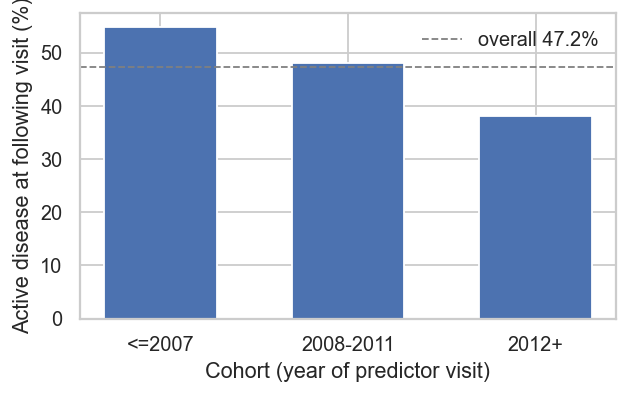

In [5]:
print('Four-category outcome at the following visit:')
print(pairs.y_next.value_counts().reindex(
    ['remission', 'low', 'medium', 'high']).to_string())

by_cohort = pairs.groupby('cohort', observed=True).y.agg(['size', 'sum', 'mean'])
by_cohort.columns = ['pairs', 'active', 'proportion']
by_cohort['proportion'] = (by_cohort.proportion * 100).round(1)
print(f'\nBinary outcome: {pairs.y.sum():,} of {len(pairs):,} active '
      f'({pairs.y.mean()*100:.1f}%)\n')
print(by_cohort.to_string())

fig, ax = plt.subplots(figsize=(5, 3.2))
vals = pairs.groupby('cohort', observed=True).y.mean() * 100
ax.bar(vals.index.astype(str), vals.values, color='#4C72B0', width=0.6)
ax.axhline(pairs.y.mean() * 100, color='grey', linestyle='--', linewidth=1,
           label=f'overall {pairs.y.mean()*100:.1f}%')
ax.set_ylabel('Active disease at following visit (%)')
ax.set_xlabel('Cohort (year of predictor visit)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/fig1_outcome_by_cohort.png', bbox_inches='tight')
plt.show()

## D. Variable distributions by cohort

Overlaid distributions allow the clinical population to be compared across periods.
The continuous panels cover the retained model predictors; the categorical panel is
descriptive and includes ethnicity, which is characterised here but excluded from the
predictor set for the reasons given in Section 3.4. Formal distributional testing is
reported separately in the drift analysis, so that the same quantity is not reported
twice.

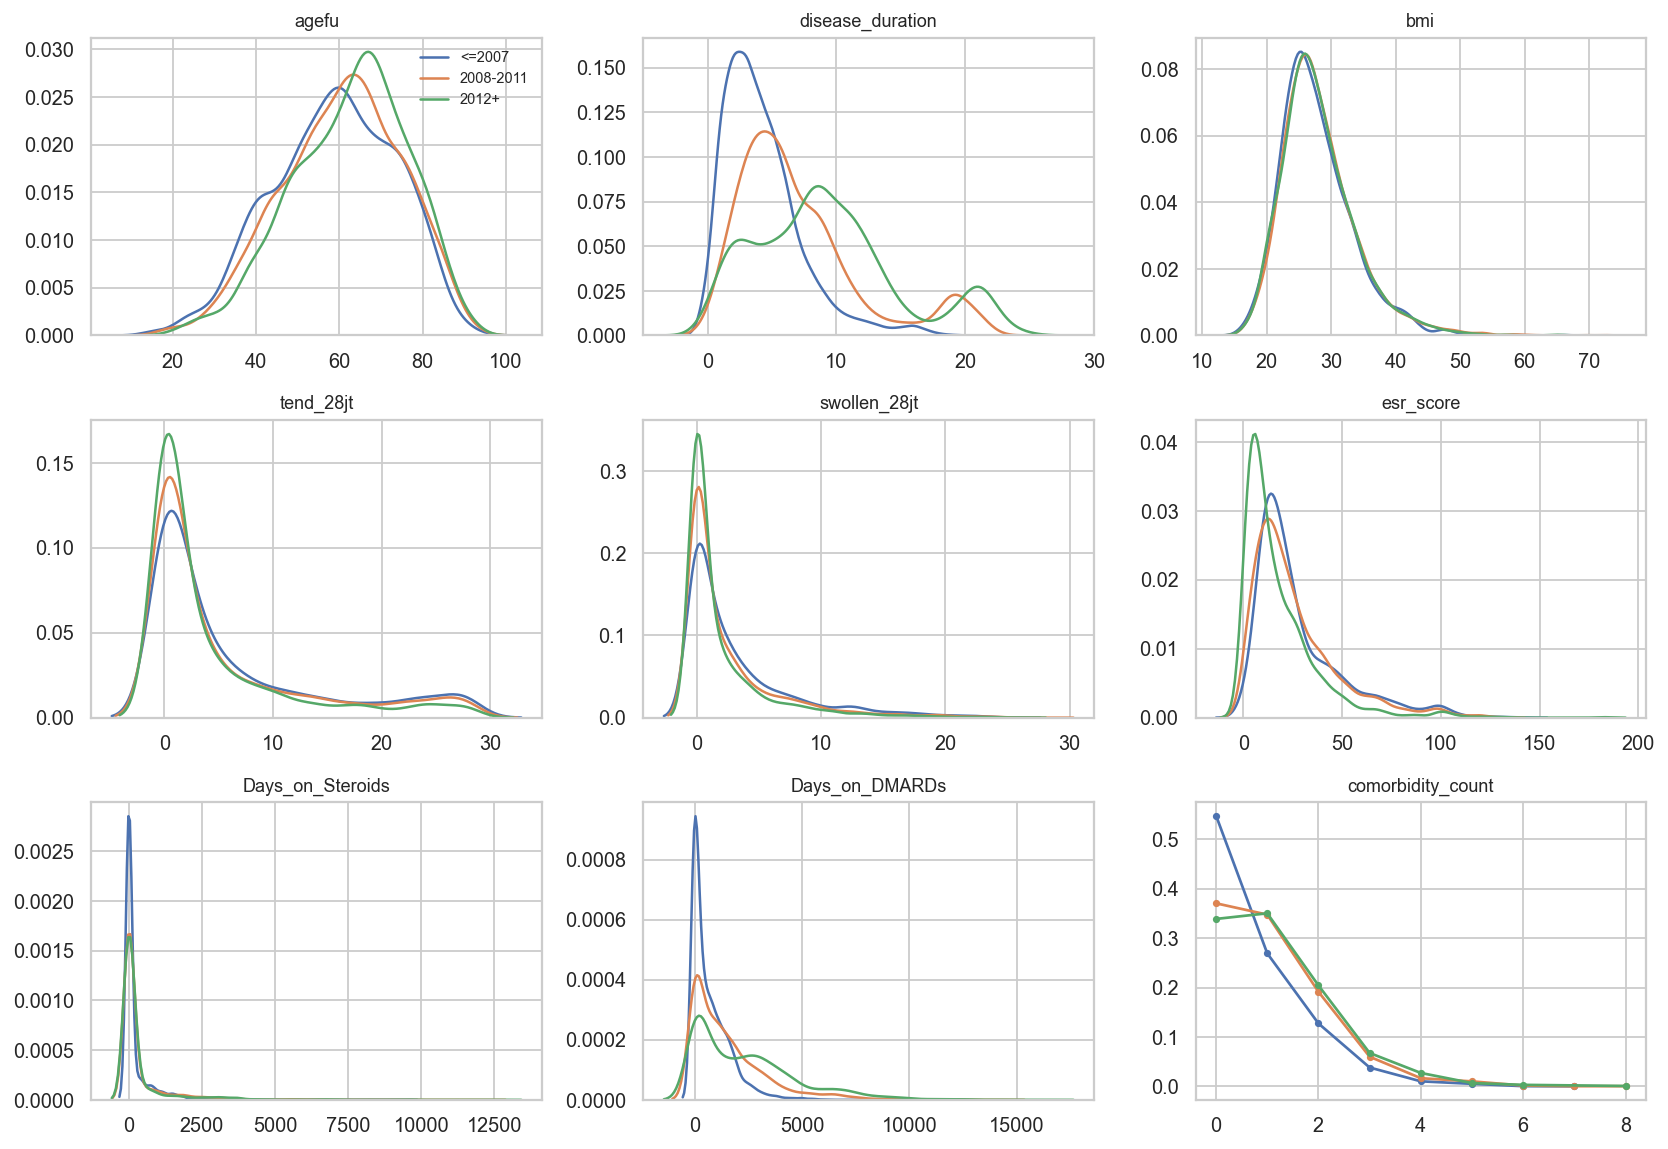

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, x in zip(axes.ravel(), MODEL_CONTINUOUS):
    for k, g in pairs.groupby('cohort', observed=True):
        s = g[x].dropna()
        if s.nunique() > 12:
            sns.kdeplot(s, ax=ax, label=str(k), linewidth=1.4)
        else:
            prop = s.value_counts(normalize=True).sort_index()
            ax.plot(prop.index, prop.values, marker='o', markersize=3, label=str(k))
    ax.set_title(x, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('')
axes.ravel()[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig('figures/fig2_continuous_by_cohort.png', bbox_inches='tight')
plt.show()

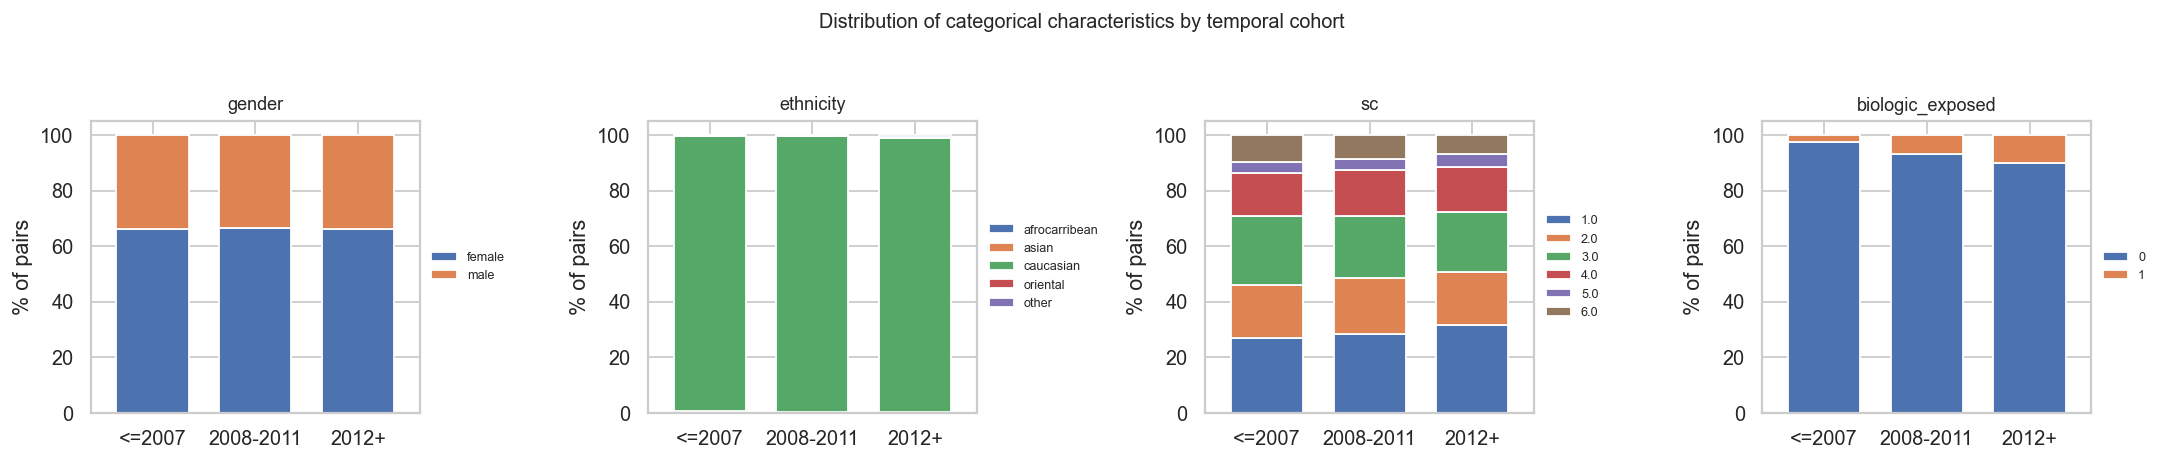

In [7]:
fig, axes = plt.subplots(1, len(DESCRIPTIVE_CATEGORICAL), figsize=(4.2 * len(DESCRIPTIVE_CATEGORICAL), 3.4))
for ax, x in zip(np.atleast_1d(axes), DESCRIPTIVE_CATEGORICAL):
    ct = pd.crosstab(pairs.cohort, pairs[x], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, width=0.7, legend=False)
    ax.set_title(x, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('% of pairs')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=7, frameon=False, loc='center left', bbox_to_anchor=(1.0, 0.5))
fig.suptitle('Distribution of categorical characteristics by temporal cohort',
             fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig('figures/fig3_categorical_by_cohort.png', bbox_inches='tight')
plt.show()

## E. Correlation among predictors

Spearman correlation is used because several predictors are skewed or ordinal. The
purpose is to identify redundancy before modelling.

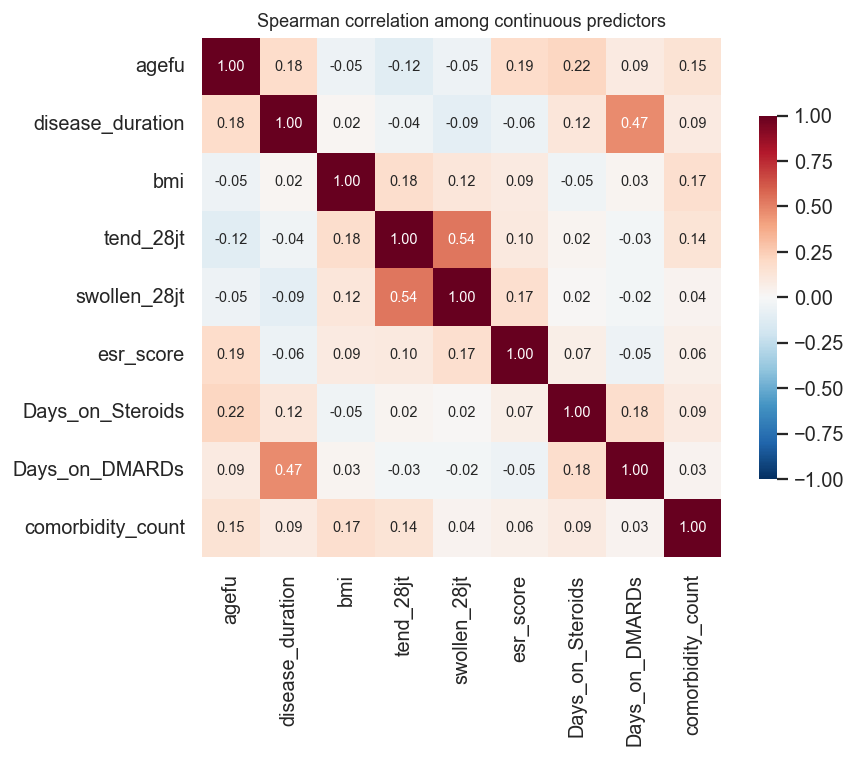

Strongest pairwise correlations:
  tend_28jt            swollen_28jt         +0.538
  Days_on_DMARDs       disease_duration     +0.473
  agefu                Days_on_Steroids     +0.216
  esr_score            agefu                +0.186
  disease_duration     agefu                +0.182
  tend_28jt            bmi                  +0.178


In [8]:
corr = pairs[MODEL_CONTINUOUS].corr(method='spearman')
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.7}, annot_kws={'size': 8}, ax=ax)
ax.set_title('Spearman correlation among continuous predictors', fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig4_correlation.png', bbox_inches='tight')
plt.show()

flat = corr.where(~np.eye(len(corr), dtype=bool)).stack()
seen, top = set(), []
for (a, b), v in flat.sort_values(key=abs, ascending=False).items():
    if (b, a) in seen:
        continue
    seen.add((a, b)); top.append((a, b, v))
print('Strongest pairwise correlations:')
for a, b, v in top[:6]:
    print(f'  {a:20s} {b:20s} {v:+.3f}')

## F. Predictors against the outcome

Unadjusted descriptive associations. The standardised difference expresses the gap
between active and inactive groups in pooled standard deviations, allowing predictors
on different scales to be compared. These are not predictive estimates.

In [9]:
rows = []
for x in MODEL_CONTINUOUS:
    a = pairs.loc[pairs.y == 1, x].dropna()
    i = pairs.loc[pairs.y == 0, x].dropna()
    pooled = np.sqrt((a.var() + i.var()) / 2)
    rows.append({'predictor': x,
                 'active_mean': round(a.mean(), 2),
                 'inactive_mean': round(i.mean(), 2),
                 'difference': round(a.mean() - i.mean(), 2),
                 'std_difference': round((a.mean() - i.mean()) / pooled, 3)
                 if pooled else np.nan})
assoc = pd.DataFrame(rows).sort_values('std_difference', key=abs, ascending=False)
print(assoc.to_string(index=False))
assoc.to_csv('outputs/table3_predictor_outcome_association.csv', index=False)
print('\nSaved outputs/table3_predictor_outcome_association.csv')

print('\nActive outcome (%) by categorical predictor:')
for x in MODEL_CATEGORICAL:
    r = pairs.groupby(x, observed=True).y.agg(['size', 'mean'])
    r['mean'] = (r['mean'] * 100).round(1)
    r.columns = ['pairs', 'active_%']
    print(f'\n{x}:'); print(r.to_string())

        predictor  active_mean  inactive_mean  difference  std_difference
        tend_28jt         9.31           1.67        7.64           1.119
     swollen_28jt         4.05           1.19        2.85           0.740
        esr_score        31.48          17.43       14.05           0.678
              bmi        29.06          27.10        1.96           0.346
comorbidity_count         1.12           0.83        0.29           0.270
 Days_on_Steroids       328.11         254.94       73.16           0.085
            agefu        60.92          60.34        0.58           0.040
   Days_on_DMARDs      1486.30        1524.77      -38.47          -0.020
 disease_duration         6.80           6.76        0.04           0.008

Saved outputs/table3_predictor_outcome_association.csv

Active outcome (%) by categorical predictor:

gender:
        pairs  active_%
gender                 
female   6843      54.3
male     3480      33.4

sc:
     pairs  active_%
sc                  
1.0   

## G. Cohort separation in predictor space

Principal component analysis is used solely as a visual check on whether cohorts occupy
different regions of the predictor space. Components are not used in modelling, as doing
so would remove the feature-level interpretability required for the explanation
analysis.

Pairs included: 9,755 of 10,323
Variance explained: PC1 20.3%, PC2 19.1%


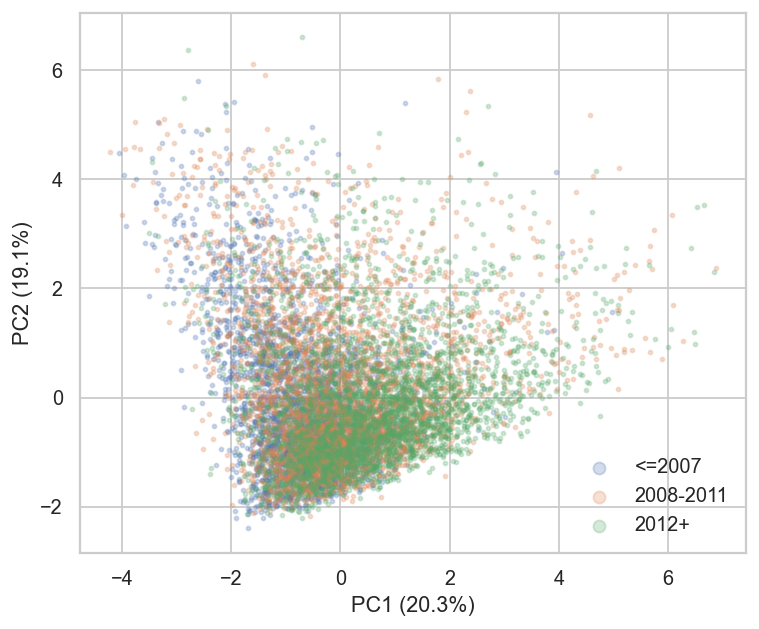


Component loadings:
                     PC1    PC2
agefu              0.367  0.111
disease_duration   0.556  0.187
bmi               -0.094  0.342
tend_28jt         -0.259  0.558
swollen_28jt      -0.292  0.530
esr_score          0.003  0.248
Days_on_Steroids   0.337  0.151
Days_on_DMARDs     0.516  0.174
comorbidity_count  0.126  0.359


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sub = pairs.dropna(subset=MODEL_CONTINUOUS)
X = StandardScaler().fit_transform(sub[MODEL_CONTINUOUS])
pca = PCA(n_components=2, random_state=0)
comp = pca.fit_transform(X)

print(f'Pairs included: {len(sub):,} of {len(pairs):,}')
print(f'Variance explained: PC1 {pca.explained_variance_ratio_[0]*100:.1f}%, '
      f'PC2 {pca.explained_variance_ratio_[1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(6, 5))
for k in ['<=2007', '2008-2011', '2012+']:
    m = (sub.cohort == k).values
    ax.scatter(comp[m, 0], comp[m, 1], s=5, alpha=0.25, label=k)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(frameon=False, markerscale=3)
plt.tight_layout()
plt.savefig('figures/fig5_pca_cohorts.png', bbox_inches='tight')
plt.show()

print('\nComponent loadings:')
print(pd.DataFrame(pca.components_.T, index=MODEL_CONTINUOUS,
                   columns=['PC1', 'PC2']).round(3).to_string())

## H. Summary

Counts and proportions reported here form the basis of Chapter 4. Formal tests of
distributional shift and explanation stability follow in notebook 03.

In [11]:
print(f'Prediction pairs                : {len(pairs):,}')
print(f'Patients                        : {pairs.regno.nunique():,}')
print(f'Predictors                      : {len(MODEL_FEATURES)}')
print(f'Active outcome                  : {pairs.y.mean()*100:.1f}%')
print(f'Complete on all predictors      : {pairs.dropna(subset=MODEL_FEATURES).shape[0]:,}')
print(f'Patients in more than one cohort: '
      f'{(pairs.groupby("regno").cohort.nunique() > 1).sum():,}')
print('\nCohorts:')
print(pairs.cohort.value_counts().sort_index().to_string())

Prediction pairs                : 10,323
Patients                        : 2,279
Predictors                      : 12
Active outcome                  : 47.2%
Complete on all predictors      : 9,370
Patients in more than one cohort: 1,499

Cohorts:
cohort
<=2007       3364
2008-2011    3888
2012+        3071
